# UC AP Volume Forecasting (2003–2035)

## Goal
Predict the percent distribution of admitted students across AP course-volume bins (<5, 5–9.9, 10+) for each UC campus for the next 10 years.

## Data
Source: `data/AP_IB_College Classes per UC - Sheet1.csv`

## Workflow
1. Load + clean + reshape to (Year, school, bins)
2. Quick EDA (trend plots)
3. Model training + evaluation (time-based split)
4. Forecast generation (next 10 years)
5. Export results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
# Load raw CSV 
ROOT = Path.cwd()
DATA_DIR = ROOT / "datasets"

UC_DIR = DATA_DIR / "uc_specific"
PREDICTION_DIR = DATA_DIR / "predictions"

df_raw = pd.read_csv(UC_DIR / "AP_IB_College Classes per UC - Sheet1.csv")

# Row 0 has school names spread across columns -> fill across
school_row = df_raw.iloc[0].ffill()

# Row 1 has bin labels under each school section
bin_row = df_raw.iloc[1]

# Map each original column -> (school, bin)
col_meta = pd.DataFrame({
    "col": df_raw.columns,
    "school": school_row.values,
    "bin": bin_row.values
})

# Actual data starts at row 2
data = df_raw.iloc[2:].copy()
data = data.rename(columns={df_raw.columns[0]: "Year"})

# Clean Year
data["Year"] = pd.to_numeric(data["Year"], errors="coerce").astype("Int64")

#Make into long form
value_cols = df_raw.columns[1:]
long = data.melt(
    id_vars=["Year"],
    value_vars=value_cols,
    var_name="col",
    value_name="percent"
)

# Attach school/bin info 
long = long.merge(col_meta, on="col", how="left")
long["percent"] = pd.to_numeric(long["percent"], errors="coerce")
long = long.dropna(subset=["Year", "school", "bin", "percent"])

# Make to wide 
wide = (
    long.pivot_table(index=["Year", "school"], columns="bin", values="percent", aggfunc="mean")
        .reset_index()
)

wide.columns.name = None  
wide = wide.sort_values(["school", "Year"]).reset_index(drop=True)

bins = ["<5.0/Unknown", "5.0 - 9.9", "10.0 or More"]
wide = wide[["Year", "school"] + bins]
wide

,Year,school,<5.0/Unknown,5.0 - 9.9,10.0 or More
0,2003,UC Berkeley,10.0,44.0,46.0
1,2004,UC Berkeley,9.0,42.0,49.0
2,2005,UC Berkeley,9.0,44.0,47.0
3,2006,UC Berkeley,9.0,42.0,50.0
4,2007,UC Berkeley,8.0,43.0,50.0
...,...,...,...,...,...
200,2021,UC Santa Cruz,20.0,46.0,34.0
201,2022,UC Santa Cruz,18.0,44.0,38.0
202,2023,UC Santa Cruz,19.0,44.0,37.0
203,2024,UC Santa Cruz,18.0,42.0,39.0


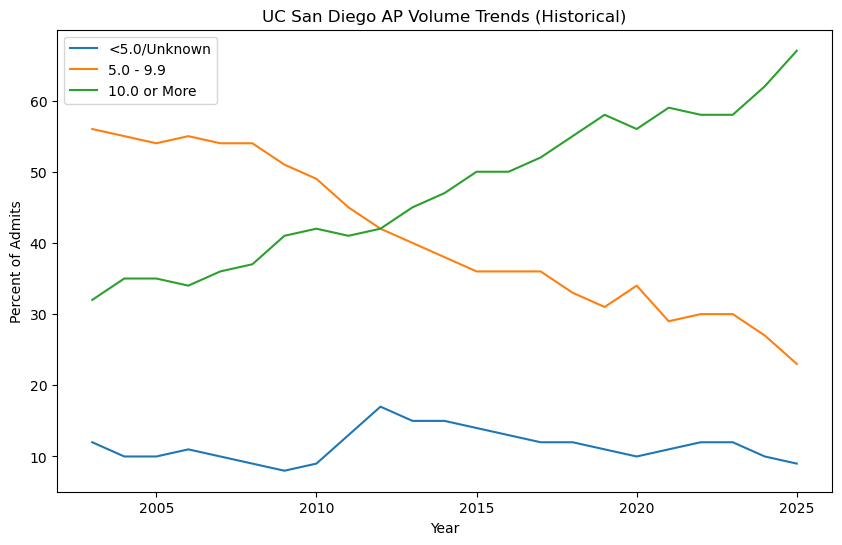

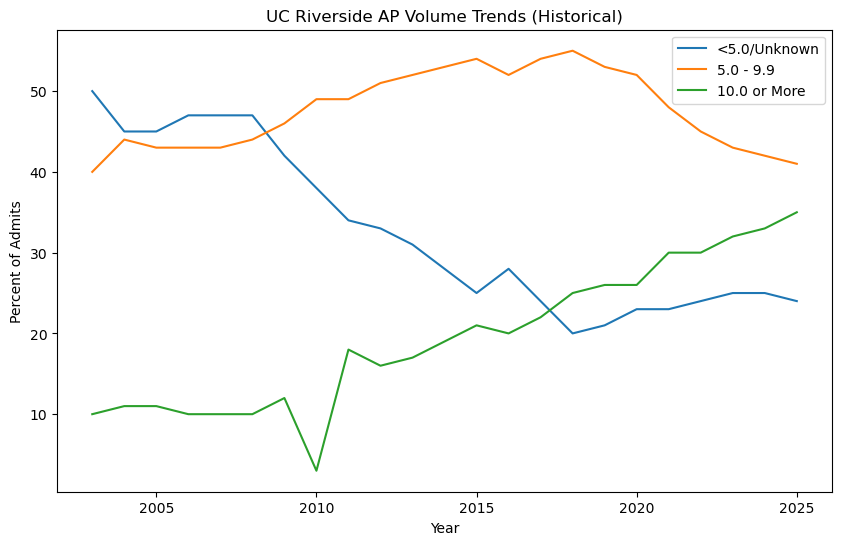

In [3]:
def plot_school_trends(wide, school, bins):
    """
    Parameters: wide (df), school (str), bins (list of str)
    Plots the AP volume trends for a given school across the bins given in the dataframe.
    Returns: None (displays a plot)
    """
    df_school = wide[wide["school"] == school].sort_values("Year")
    plt.figure(figsize=(10,6))
    for b in bins:
        plt.plot(df_school["Year"], df_school[b], label=b)
    plt.title(f"{school} AP Volume Trends (Historical)")
    plt.xlabel("Year")
    plt.ylabel("Percent of Admits")
    plt.legend()
    plt.show()

plot_school_trends(wide, "UC San Diego", bins)
plot_school_trends(wide, "UC Riverside", bins)

In [4]:
def compare_degrees(df_school, bins, degrees=(1, 2, 3), test_years=5):
    """
    Parameters: df_school (df), bins (list of str), degrees (tuple of int), test_years (int)
    Compares polynomial regression models of different degrees for predicting AP volume trends for a given school.
    Uses the last `test_years` for testing and the rest for training. Evaluates using MAE.
    Returns: DataFrame with degree and corresponding MAE, sorted by MAE
    """
    df_school = df_school.sort_values("Year")

    X = df_school[["Year"]].values
    y = df_school[bins].values

    X_train, X_test = X[:-test_years], X[-test_years:]
    y_train, y_test = y[:-test_years], y[-test_years:]

    results = []

    for d in degrees:
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("reg", MultiOutputRegressor(Ridge(alpha=1.0)))
        ])

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        results.append((d, mae))

    return pd.DataFrame(results, columns=["Degree", "MAE"]).sort_values("MAE")

ucsd = wide[wide["school"] == "UC San Diego"]
compare_degrees(ucsd, bins)

/opt/anaconda3/envs/UCcostenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.39965e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/UCcostenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.39965e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/UCcostenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.39965e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,Degree,MAE
0,1,2.242125
1,2,2.276116
2,3,2.589348


A linear model appears the best, so we will use that.

In [5]:
def train_eval_forecast(df_school, school_name, bins, degree=1, alpha=1.0, test_years=5, horizon=5):
    """
    Parameters: df_school (df), school_name (str), bins (list of str), degree (int), alpha (float), test_years (int), horizon (int)
    Trains a polynomial regression model of degree (degree) to predict AP volume trends for a given school, 
    evaluates on the last `test_years`, and forecasts for the next `horizon` years.
    Returns: model, dict of MAE per bin, overall MAE, and forecast DataFrame
    """
    # prepare data 
    df_school = df_school.sort_values("Year").copy()
    X = df_school[["Year"]].values
    y = df_school[bins].values

    # split data
    X_train, X_test = X[:-test_years], X[-test_years:]
    y_train, y_test = y[:-test_years], y[-test_years:]

    # model
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("reg", MultiOutputRegressor(Ridge(alpha=alpha)))
    ])

    model.fit(X_train, y_train)

    # evaluation
    pred_test = model.predict(X_test)

    mae_per_bin = {
        bins[i]: mean_absolute_error(y_test[:, i], pred_test[:, i])
        for i in range(len(bins))
    }
    mae_overall = mean_absolute_error(y_test, pred_test)

    # forecast 
    last_year = int(df_school["Year"].max())
    future_years = np.arange(last_year + 1, last_year + horizon + 1).reshape(-1, 1)

    future_pred = model.predict(future_years)

    # Keep non-negative and renormalize to sum to 100
    future_pred = np.maximum(future_pred, 0)
    row_sums = future_pred.sum(axis=1, keepdims=True)
    future_pred = 100 * future_pred / row_sums
    
    forecast = pd.DataFrame(future_pred, columns=bins)
    forecast.insert(0, "Year", future_years.flatten())
    forecast.insert(1, "school", school_name)

    return model, mae_per_bin, mae_overall, forecast

In [6]:
"""
Train, evaluate, and forecast for all schools. Collect forecasts and MAE results.
Create a combined DataFrame of forecasts for all schools.
"""
schools = wide["school"].unique()

all_forecasts = []
all_mae = {}

for school in schools:
    df_school = wide[wide["school"] == school].sort_values("Year")
    
    model, mae_per_bin, mae_overall, forecast = train_eval_forecast(
        df_school, school, bins, degree=1
    )
    
    all_forecasts.append(forecast)
    all_mae[school] = mae_overall

predictions = pd.concat(all_forecasts)

In [7]:
predictions.to_csv(PREDICTION_DIR / "school_AP_volume_predictions_5yr.csv")